In [42]:
import numpy as np
import os
from implementations.DT import DecisionTree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Assuming first_test_tree.feature_importances is a dictionary or array of feature importances
import matplotlib.pyplot as plt
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np


In [2]:
# Load post-PCA subsets
data_folder = 'data/post_pca_subsets'
X_train = np.load(os.path.join(data_folder, 'X_train.npy'))
X_validate = np.load(os.path.join(data_folder, 'X_validate.npy'))
Y_train = np.load(os.path.join(data_folder, 'Y_train.npy'))
Y_validate = np.load(os.path.join(data_folder, 'Y_validate.npy'))

In [6]:
# Initialize variables to track the best model and score
best_score = -float('inf')  # Initialize to a very low value
best_params = None  # To store the best hyperparameters
best_model = None  # To store the best trained model

# Grid search over the reduced hyperparameters
for max_depth in max_depth_options:
    for min_samples_leaf in min_samples_leaf_options:
        for min_information_gain in min_information_gain_options:
            for numb_of_features_splitting in numb_of_features_splitting_options:
                print(f"Testing: max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, "
                      f"min_information_gain={min_information_gain}, numb_of_features_splitting={numb_of_features_splitting}")
                
                # Initialize and train the Decision Tree with current parameters
                model = DecisionTree(
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_information_gain=min_information_gain,
                    numb_of_features_splitting=numb_of_features_splitting
                )
                model.train(X_train, Y_train)  # Train the model
                
                # Predict on validation set and calculate accuracy
                Y_pred = model.predict(X_validate)
                score = accuracy_score(Y_validate, Y_pred)  # Compute accuracy
                
                # Update best model if current score is higher
                if score > best_score:
                    best_score = score
                    best_params = {
                        'max_depth': max_depth,
                        'min_samples_leaf': min_samples_leaf,
                        'min_information_gain': min_information_gain,
                        'numb_of_features_splitting': numb_of_features_splitting
                    }
                    best_model = model  # Store the best model

print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy: {best_score * 100:.2f}%")


Testing: max_depth=5, min_samples_leaf=5, min_information_gain=0.01, numb_of_features_splitting=sqrt
Testing: max_depth=5, min_samples_leaf=5, min_information_gain=0.05, numb_of_features_splitting=sqrt
Testing: max_depth=5, min_samples_leaf=10, min_information_gain=0.01, numb_of_features_splitting=sqrt
Testing: max_depth=5, min_samples_leaf=10, min_information_gain=0.05, numb_of_features_splitting=sqrt
Testing: max_depth=10, min_samples_leaf=5, min_information_gain=0.01, numb_of_features_splitting=sqrt
Testing: max_depth=10, min_samples_leaf=5, min_information_gain=0.05, numb_of_features_splitting=sqrt
Testing: max_depth=10, min_samples_leaf=10, min_information_gain=0.01, numb_of_features_splitting=sqrt
Testing: max_depth=10, min_samples_leaf=10, min_information_gain=0.05, numb_of_features_splitting=sqrt

Best Hyperparameters:
{'max_depth': 10, 'min_samples_leaf': 5, 'min_information_gain': 0.01, 'numb_of_features_splitting': 'sqrt'}
Best Validation Accuracy: 69.25%


In [7]:
# Initialize your custom Decision Tree with specific parameters
first_test_tree = DecisionTree(
    max_depth=10,                  # Maximum depth of the tree
    min_samples_leaf=5,            # Minimum number of samples per leaf node
    min_information_gain=0.01,     # Minimum information gain required to split
    numb_of_features_splitting='sqrt'  # Number of features to consider when splitting
)

In [11]:
# Load the post-PCA test set
data_folder = 'data/post_pca_subsets'
X_test = np.load(os.path.join(data_folder, 'X_test.npy'))
Y_test = np.load(os.path.join(data_folder, 'Y_test.npy'))

print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")


X_test shape: (2000, 62)
Y_test shape: (2000,)


In [12]:
# Train the decision tree on the training set
first_test_tree.train(X_train, Y_train)
print("Decision Tree training completed.")

# Predict the labels for the validation set
Y_pred = first_test_tree.predict(X_validate)

# Evaluate the performance of the model on the validation set
accuracy = accuracy_score(Y_validate, Y_pred)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

# Display a classification report for detailed performance metrics
print("Classification Report (Validation Set):")
print(classification_report(Y_validate, Y_pred))

# Predict the labels for the test set
Y_test_pred = first_test_tree.predict(X_test)

# Evaluate the performance of the model on the test set
test_accuracy = accuracy_score(Y_test, Y_test_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Display a classification report for the test set
print("\nClassification Report (Test Set):")
print(classification_report(Y_test, Y_test_pred))

Decision Tree training completed.
Validation Accuracy: 69.80%
Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       407
           1       0.84      0.89      0.86       389
           2       0.68      0.73      0.71       400
           3       0.69      0.72      0.71       401
           4       0.56      0.50      0.53       403

    accuracy                           0.70      2000
   macro avg       0.69      0.70      0.70      2000
weighted avg       0.69      0.70      0.69      2000

Test Accuracy: 74.00%

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.71      0.72      0.72       407
           1       0.84      0.90      0.87       389
           2       0.73      0.78      0.76       400
           3       0.79      0.75      0.77       401
           4       0.61      0.54      0.57       403

    accuracy              

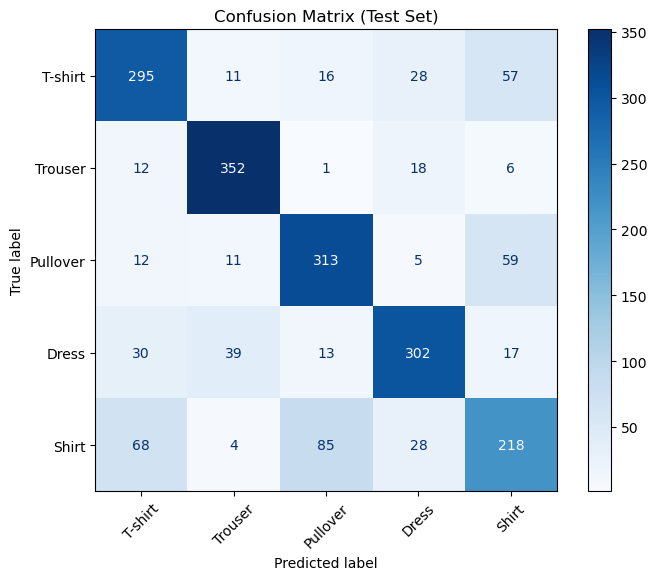

In [13]:
f# Compute confusion matrix
cm = confusion_matrix(Y_test, Y_test_pred)  # Ensure Y_test and Y_test_pred are correctly used

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size for better readability
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix (Test Set)')
plt.xticks(rotation=45)  # Rotate x-tick labels for clarity
plt.show()


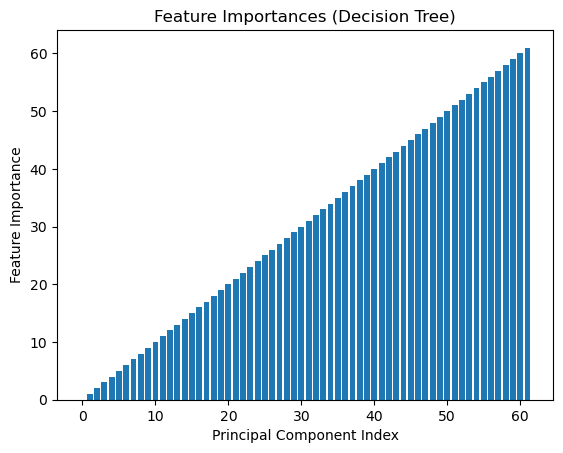

In [14]:


feature_importances = first_test_tree.feature_importances
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Principal Component Index")
plt.ylabel("Feature Importance")
plt.title("Feature Importances (Decision Tree)")
plt.show()

In [33]:
import numpy as np

class FeedForwardNeuralNetwork:
    def __init__(self, input_dim, hidden_dims, output_dim, learning_rate=0.001):
        """Initialize the neural network."""
        self.learning_rate = learning_rate
        self.weights = []
        self.biases = []

        # Initialize weights and biases
        self.weights.append(np.random.randn(input_dim, hidden_dims[0]) * 0.01)
        self.biases.append(np.zeros((1, hidden_dims[0])))

        for i in range(1, len(hidden_dims)):
            self.weights.append(np.random.randn(hidden_dims[i - 1], hidden_dims[i]) * 0.01)
            self.biases.append(np.zeros((1, hidden_dims[i])))

        self.weights.append(np.random.randn(hidden_dims[-1], output_dim) * 0.01)
        self.biases.append(np.zeros((1, output_dim)))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return Z > 0

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        A = X
        self.cache = {'A0': A}
        for i in range(len(self.weights) - 1):
            Z = np.dot(A, self.weights[i]) + self.biases[i]
            A = self.relu(Z)
            self.cache[f'Z{i + 1}'] = Z
            self.cache[f'A{i + 1}'] = A

        Z = np.dot(A, self.weights[-1]) + self.biases[-1]
        A = self.softmax(Z)
        self.cache[f'Z{len(self.weights)}'] = Z
        self.cache[f'A{len(self.weights)}'] = A
        return A

    def compute_loss(self, Y, Y_hat):
        m = Y.shape[0]
        log_probs = -np.log(Y_hat[range(m), Y])
        loss = np.sum(log_probs) / m
        return loss

    def predict(self, X):
        Y_hat = self.forward_propagation(X)
        return np.argmax(Y_hat, axis=1)

    def evaluate(self, X, Y):
        """Evaluate the model on a dataset and return the loss and accuracy."""
        Y_hat = self.forward_propagation(X)
        loss = self.compute_loss(Y, Y_hat)
        Y_pred = np.argmax(Y_hat, axis=1)
        accuracy = np.mean(Y_pred == Y)
        return loss, accuracy

    def backward_propagation(self, X, Y):
        m = X.shape[0]
        grads = {}

        A_out = self.cache[f'A{len(self.weights)}']
        A_out[range(m), Y] -= 1
        grads[f'dZ{len(self.weights)}'] = A_out / m

        for i in reversed(range(len(self.weights))):
            dZ = grads[f'dZ{i + 1}']
            A_prev = self.cache[f'A{i}'] if i > 0 else X
            grads[f'dW{i + 1}'] = np.dot(A_prev.T, dZ)
            grads[f'db{i + 1}'] = np.sum(dZ, axis=0, keepdims=True)

            if i > 0:
                dA_prev = np.dot(dZ, self.weights[i].T)
                dZ_prev = dA_prev * self.relu_derivative(self.cache[f'Z{i}'])
                grads[f'dZ{i}'] = dZ_prev

        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * grads[f'dW{i + 1}']
            self.biases[i] -= self.learning_rate * grads[f'db{i + 1}']

    def train(self, X, Y, epochs=20, batch_size=32):
        for epoch in range(epochs):
            permutation = np.random.permutation(X.shape[0])
            X_shuffled = X[permutation]
            Y_shuffled = Y[permutation]

            for i in range(0, X.shape[0], batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                Y_batch = Y_shuffled[i:i + batch_size]

                Y_hat = self.forward_propagation(X_batch)
                self.backward_propagation(X_batch, Y_batch)

            Y_hat_full = self.forward_propagation(X)
            loss = self.compute_loss(Y, Y_hat_full)
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}")


Epoch 1/20, Loss: 1.6083
Epoch 2/20, Loss: 1.6050
Epoch 3/20, Loss: 1.5869
Epoch 4/20, Loss: 1.4379
Epoch 5/20, Loss: 1.1832
Epoch 6/20, Loss: 1.1123
Epoch 7/20, Loss: 1.0836
Epoch 8/20, Loss: 1.0572
Epoch 9/20, Loss: 1.0291
Epoch 10/20, Loss: 0.9981
Epoch 11/20, Loss: 0.9687
Epoch 12/20, Loss: 0.9434
Epoch 13/20, Loss: 0.9232
Epoch 14/20, Loss: 0.9071
Epoch 15/20, Loss: 0.8941
Epoch 16/20, Loss: 0.8836
Epoch 17/20, Loss: 0.8749
Epoch 18/20, Loss: 0.8663
Epoch 19/20, Loss: 0.8612
Epoch 20/20, Loss: 0.8548

Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.60      0.71      0.65       407
     Trouser       0.92      0.95      0.94       389
    Pullover       0.58      0.83      0.68       400
       Dress       0.80      0.70      0.74       401
       Shirt       0.34      0.17      0.23       403

    accuracy                           0.67      2000
   macro avg       0.65      0.67      0.65      2000
weighted avg       0.65      0.

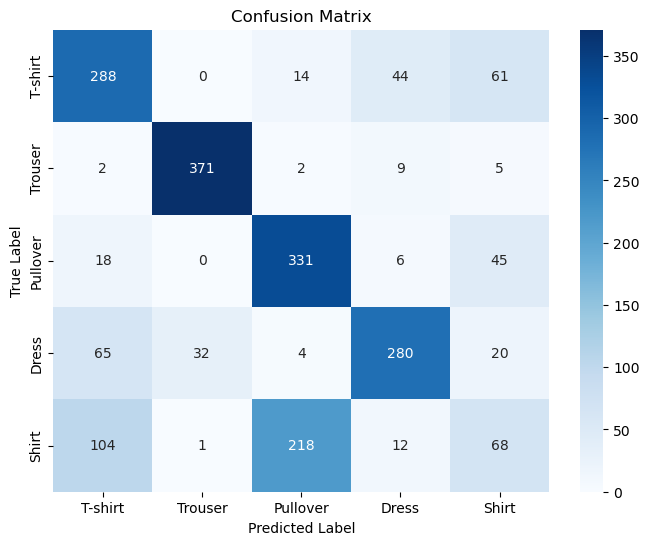

In [34]:
# Define the topology: 784 input neurons, two hidden layers with 128 and 64 neurons, 5 output neurons
input_dim = X_train.shape[1]
output_dim = len(np.unique(Y_train))
hidden_dims = [128, 64]

# Create and train the neural network
ffnn_scratch = NeuralNet(topology=[input_dim] + hidden_dims + [output_dim], learning_rate=0.01)
ffnn_scratch.train(X_train, Y_train, epochs=20, batch_size=32)

# Predict on the test set
Y_test_pred = ffnn_scratch.predict(X_test)

# Display the classification report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(Y_test, Y_test_pred, target_names=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt']))

# Plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(Y_test, Y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'],
            yticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [35]:
def train_model(X_train, Y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    # Create a neural network model using your FeedForwardNeuralNetwork class
    hidden_dims = [num_nodes]  # One hidden layer with 'num_nodes' units
    output_dim = len(np.unique(Y_train))
    
    model = FeedForwardNeuralNetwork(input_dim=X_train.shape[1], hidden_dims=hidden_dims, output_dim=output_dim, learning_rate=lr)
    
    # Train the model
    history = model.train(X_train, Y_train, epochs=epochs, batch_size=batch_size)
    
    return model, history


In [38]:
least_val_loss = float('inf')
least_loss_model = None
best_params = {}  # To store the best hyperparameters
epochs = 100

for num_nodes in [16, 32, 64]:
    for lr in [0.01, 0.005, 0.001]:
        for batch_size in [32, 64, 128]:
            print(f"Training model with {num_nodes} nodes, lr={lr}, batch_size={batch_size}")
            
            model = FeedForwardNeuralNetwork(
                input_dim=X_train.shape[1],
                hidden_dims=[num_nodes],
                output_dim=len(np.unique(Y_train)),
                learning_rate=lr
            )
            
            model.train(X_train, Y_train, epochs=epochs, batch_size=batch_size)
            
            val_loss, val_acc = model.evaluate(X_validate, Y_validate)
            print(f"Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}")
            
            if val_loss < least_val_loss:
                least_val_loss = val_loss
                least_loss_model = model
                best_params = {
                    'num_nodes': num_nodes,
                    'learning_rate': lr,
                    'batch_size': batch_size
                }

print(f"\nBest model found with validation loss: {least_val_loss:.4f}")
print(f"Best hyperparameters: {best_params}")


Training model with 16 nodes, lr=0.01, batch_size=32
Epoch 1/100, Loss: 1.5982
Epoch 2/100, Loss: 1.4672
Epoch 3/100, Loss: 1.1016
Epoch 4/100, Loss: 0.8595
Epoch 5/100, Loss: 0.7299
Epoch 6/100, Loss: 0.6712
Epoch 7/100, Loss: 0.6384
Epoch 8/100, Loss: 0.6154
Epoch 9/100, Loss: 0.5963
Epoch 10/100, Loss: 0.5772
Epoch 11/100, Loss: 0.5597
Epoch 12/100, Loss: 0.5414
Epoch 13/100, Loss: 0.5259
Epoch 14/100, Loss: 0.5126
Epoch 15/100, Loss: 0.5019
Epoch 16/100, Loss: 0.4912
Epoch 17/100, Loss: 0.4830
Epoch 18/100, Loss: 0.4764
Epoch 19/100, Loss: 0.4689
Epoch 20/100, Loss: 0.4629
Epoch 21/100, Loss: 0.4576
Epoch 22/100, Loss: 0.4529
Epoch 23/100, Loss: 0.4484
Epoch 24/100, Loss: 0.4444
Epoch 25/100, Loss: 0.4407
Epoch 26/100, Loss: 0.4368
Epoch 27/100, Loss: 0.4338
Epoch 28/100, Loss: 0.4303
Epoch 29/100, Loss: 0.4278
Epoch 30/100, Loss: 0.4248
Epoch 31/100, Loss: 0.4238
Epoch 32/100, Loss: 0.4210
Epoch 33/100, Loss: 0.4183
Epoch 34/100, Loss: 0.4168
Epoch 35/100, Loss: 0.4134
Epoch 36/10

In [40]:
# Combine X_train and X_validate, Y_train and Y_validate for final training
X_final_train = np.vstack((X_train, X_validate))  # Stack training and validation data
Y_final_train = np.hstack((Y_train, Y_validate))

# Best hyperparameters from the hyperparameter search
best_num_nodes = best_params['num_nodes']
best_lr = best_params['learning_rate']
best_batch_size = best_params['batch_size']

# Reinitialize the model with the best hyperparameters
final_model = FeedForwardNeuralNetwork(
    input_dim=X_final_train.shape[1],
    hidden_dims=[best_num_nodes],
    output_dim=len(np.unique(Y_final_train)),
    learning_rate=best_lr
)

# Train the model on the combined training and validation set
final_model.train(X_final_train, Y_final_train, epochs=epochs, batch_size=best_batch_size)

# Evaluate the final model on the test set
test_loss, test_accuracy = final_model.evaluate(X_test, Y_test)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Epoch 1/100, Loss: 1.4905
Epoch 2/100, Loss: 1.0668
Epoch 3/100, Loss: 0.7970
Epoch 4/100, Loss: 0.6789
Epoch 5/100, Loss: 0.6274
Epoch 6/100, Loss: 0.5928
Epoch 7/100, Loss: 0.5637
Epoch 8/100, Loss: 0.5391
Epoch 9/100, Loss: 0.5189
Epoch 10/100, Loss: 0.5020
Epoch 11/100, Loss: 0.4876
Epoch 12/100, Loss: 0.4761
Epoch 13/100, Loss: 0.4659
Epoch 14/100, Loss: 0.4570
Epoch 15/100, Loss: 0.4492
Epoch 16/100, Loss: 0.4423
Epoch 17/100, Loss: 0.4354
Epoch 18/100, Loss: 0.4291
Epoch 19/100, Loss: 0.4245
Epoch 20/100, Loss: 0.4178
Epoch 21/100, Loss: 0.4143
Epoch 22/100, Loss: 0.4100
Epoch 23/100, Loss: 0.4059
Epoch 24/100, Loss: 0.4023
Epoch 25/100, Loss: 0.3994
Epoch 26/100, Loss: 0.3962
Epoch 27/100, Loss: 0.3927
Epoch 28/100, Loss: 0.3902
Epoch 29/100, Loss: 0.3880
Epoch 30/100, Loss: 0.3860
Epoch 31/100, Loss: 0.3829
Epoch 32/100, Loss: 0.3809
Epoch 33/100, Loss: 0.3789
Epoch 34/100, Loss: 0.3768
Epoch 35/100, Loss: 0.3745
Epoch 36/100, Loss: 0.3747
Epoch 37/100, Loss: 0.3708
Epoch 38/1

# M2

Epoch 1/20


2025-01-05 03:36:00.664351: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


188/188 [==============================] - 0s 1ms/step - loss: 0.8032 - accuracy: 0.6923 - val_loss: 0.4673 - val_accuracy: 0.8310
Epoch 2/20
188/188 [==============================] - 0s 579us/step - loss: 0.5040 - accuracy: 0.8102 - val_loss: 0.4047 - val_accuracy: 0.8465
Epoch 3/20
188/188 [==============================] - 0s 579us/step - loss: 0.4488 - accuracy: 0.8273 - val_loss: 0.3781 - val_accuracy: 0.8520
Epoch 4/20
188/188 [==============================] - 0s 685us/step - loss: 0.4103 - accuracy: 0.8422 - val_loss: 0.3614 - val_accuracy: 0.8600
Epoch 5/20
188/188 [==============================] - 0s 571us/step - loss: 0.3868 - accuracy: 0.8522 - val_loss: 0.3541 - val_accuracy: 0.8630
Epoch 6/20
188/188 [==============================] - 0s 566us/step - loss: 0.3654 - accuracy: 0.8625 - val_loss: 0.3461 - val_accuracy: 0.8635
Epoch 7/20
188/188 [==============================] - 0s 567us/step - loss: 0.3553 - accuracy: 0.8668 - val_loss: 0.3387 - val_accuracy: 0.8680
Epoch

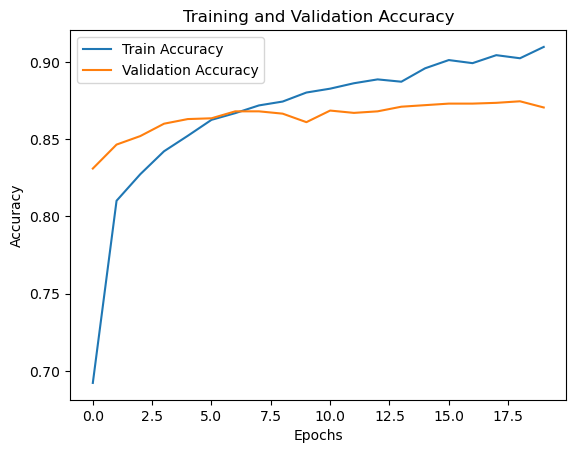

63/63 [==============================] - 0s 300us/step

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       407
           1       0.98      0.98      0.98       389
           2       0.86      0.91      0.88       400
           3       0.90      0.90      0.90       401
           4       0.75      0.72      0.73       403

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



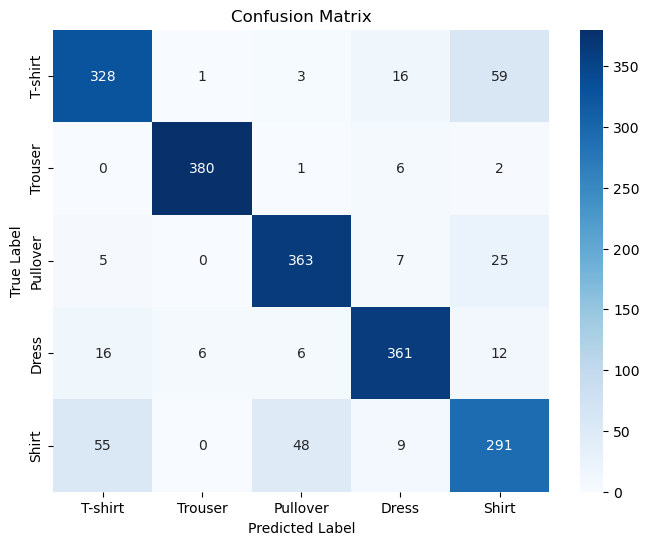

In [ ]:
# Set random seed for reproducibility
tf.random.set_seed(43)

# Load post-PCA subsets
data_folder = 'data/post_pca_subsets'
X_train = np.load(os.path.join(data_folder, 'X_train.npy'))
X_validate = np.load(os.path.join(data_folder, 'X_validate.npy'))
Y_train = np.load(os.path.join(data_folder, 'Y_train.npy'))
Y_validate = np.load(os.path.join(data_folder, 'Y_validate.npy'))
X_test = np.load(os.path.join(data_folder, 'X_test.npy'))
Y_test = np.load(os.path.join(data_folder, 'Y_test.npy'))

# Define the neural network model
def create_ffnn(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),  # First hidden layer with 128 neurons
        Dropout(0.3),                                              # Dropout to prevent overfitting
        Dense(64, activation='relu'),                              # Second hidden layer with 64 neurons
        Dropout(0.2),                                              # Dropout to prevent overfitting
        Dense(output_dim, activation='softmax')                    # Output layer with softmax activation
    ])
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',  # Use sparse categorical cross-entropy for integer labels
        metrics=['accuracy']
    )
    
    return model

# Create the FFNN model
input_dim = X_train.shape[1]  # Number of features (input dimension)
output_dim = len(np.unique(Y_train))  # Number of unique classes (output dimension)
ffnn_model = create_ffnn(input_dim, output_dim)

# Train the model
history = ffnn_model.fit(
    X_train, Y_train,
    validation_data=(X_validate, Y_validate),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_acc = ffnn_model.evaluate(X_test, Y_test, verbose=2)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Predict on the test set
Y_test_pred = ffnn_model.predict(X_test).argmax(axis=1)

# Display classification report
print("\nClassification Report:")
print(classification_report(Y_test, Y_test_pred))

# Plot confusion matrix
cm = confusion_matrix(Y_test, Y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'],
            yticklabels=['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Shirt'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


# M2 using the py libraries